In [3]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

dataset_path = "../data/merged_dataset.csv"

df = pd.read_csv(dataset_path)

df.head()

,country_name,country_code,year,suicide_data,homicide_data,intentional_death,gini_index
0,albania,alb,2002,4.48,216.0,220.48,0.32
1,albania,alb,2005,6.91,154.0,160.91,0.31
2,albania,alb,2008,6.95,93.0,99.95,0.30
3,albania,alb,2012,4.09,157.0,161.09,0.29
4,albania,alb,2014,3.80,134.0,137.80,0.35


### Hypotheses

- H₀: There is no positive relationship between suicide and homicide death.
- H₁: There is a positive relationship between suicide and homicide death.


##### Rationale — Why is this hypothesis relevant?

This hypothesis helps you examine whether countries (or regions) with higher suicide rates tend to also have higher homicide rates. Testing this matters because:

- Suicide and homicide are both types of intentional deaths, often influenced by socioeconomic, psychological, and societal factors (in our case mainly focused on economic inequality).
- Understanding whether they move together (positive correlation) can help policymakers, public-health officials, and researchers: Identify shared underlying causes (e.g., inequality, mental-health issues, social instability).
- Design combined intervention strategies rather than treating these issues independently.
- A positive relationship would suggest that these factors may co-occur in certain environments, providing insights for risk assessment and prevention programs.

In summary, this hypothesis is relevant because it tests whether suicide and homicide deaths are statistically related, which can guide deeper analysis into intentional death patterns and support data-driven decision-making.

### Variables Involved
1. Suicide death rate
- Numerical value representing the number of suicide deaths per 100,000 (or another population unit).
- Used to measure intentional self-harm mortality.

2. Homicide death rate
- Numerical value representing the number of homicide deaths per 100,000 population.
- Used to measure intentional interpersonal violence mortality.

### Type of Variables
- Both variables are continuous variables.
- They are measured on a ratio scale (they have a meaningful zero and can take a wide range of numerical values).
- You can compute averages, correlations, and other statistical measures with them.

### Independent and Dependent Variable

For a correlation hypothesis, there is no strict independent or dependent variable because correlation examines association, not cause and effect.
However, if your analysis or research context requires labeling them:
- Independent variable (IV): Suicide death rate
- Dependent variable (DV): Homicide death rate
This assignment is only for interpretation purposes; correlation itself does not assume causality.

### Pearson correlation on log-transformed homicide_data.

In [6]:
from scipy.stats import pearsonr, spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

filtered_df = df[(df['year'].isin([2000, 2005])) | (df['year'].isin([2010, 2015]))]
filtered_df.head()

filtered_df = filtered_df.copy()
filtered_df["log_homicide"] = np.log(filtered_df["homicide_data"] + 1)


# ----------------------------------------------------------
# Log-transform homicide data (due to extreme skew)
# ----------------------------------------------------------
filtered_df["log_homicide"] = np.log(filtered_df["homicide_data"] + 1)

# ----------------------------------------------------------
# Pearson Correlation (recommended)
# ----------------------------------------------------------
pear_corr, pear_p = pearsonr(filtered_df["suicide_data"], filtered_df["log_homicide"])

print("Pearson Correlation (suicide vs log_homicide):", pear_corr)
print("One-tailed p-value (H1: positive):", pear_p / 2 if pear_corr > 0 else 1 - pear_p/2)

# ----------------------------------------------------------
# Spearman Rank Correlation (non-parametric, also useful)
# ----------------------------------------------------------
spear_corr, spear_p = spearmanr(filtered_df["suicide_data"], filtered_df["homicide_data"])

print("\nSpearman Correlation (suicide vs homicide):", spear_corr)
print("One-tailed p-value (H1: positive):", spear_p / 2 if spear_corr > 0 else 1 - spear_p/2)

Pearson Correlation (suicide vs log_homicide): 0.026153731118678105
One-tailed p-value (H1: positive): 0.34983030888480626

Spearman Correlation (suicide vs homicide): -0.14299125721046324
One-tailed p-value (H1: positive): 0.9829854040151375


#### Interpretation

Pearson r = 0.026 (near zero)
- This indicates almost no linear relationship between suicide and log-transformed homicide rates.

One-tailed p-value = 0.3498
- This p-value is much larger than 0.05.
- Means there is no statistical evidence supporting a positive association.

The linear relationship between suicide and homicide rates is extremely weak and statistically non-significant. There is no evidence that higher homicide rates correspond to higher suicide rates


Spearman ρ = –0.143 (weak negative)
- Spearman examines monotonic (rank-based) patterns.
- A negative value means as homicide increases, suicide tends to decrease slightly.

One-tailed p-value = 0.9830
- HUGE p-value → no support for a positive relationship
- This p-value also strongly rejects H₁ (positive direction)

There is a weak negative monotonic association between suicide and homicide rates. However, this relationship is extremely small and statistically non-significant. There is no evidence of a positive relationship.


Both methods show:

- The relationship between suicide and homicide is extremely weak
- The direction is either near zero (Pearson) or slightly negative (Spearman)
- The p-values are very large, meaning:
    - The observed relationship could easily happen by random chance
- There is no statistical support for the idea that suicide and homicide rise together

### Conclusion (Hypothesis Decision)

Fail to Reject H₀ (Null Hypothesis)
- There is no evidence of a positive relationship between suicide and homicide deaths.

H₁ (Positive relationship) is NOT supported
- In fact, the Spearman result suggests the opposite direction (slightly negative), although still non-significant.

In [8]:
# ---------------------------------------------
# 3. Visual Correlation Matrices
# ---------------------------------------------
# Select numeric columns for correlation matrix
numeric_cols = ["suicide_data", "homicide_data", "intentional_death", "gini_index"]

corr_matrix = filtered_df[numeric_cols].corr()


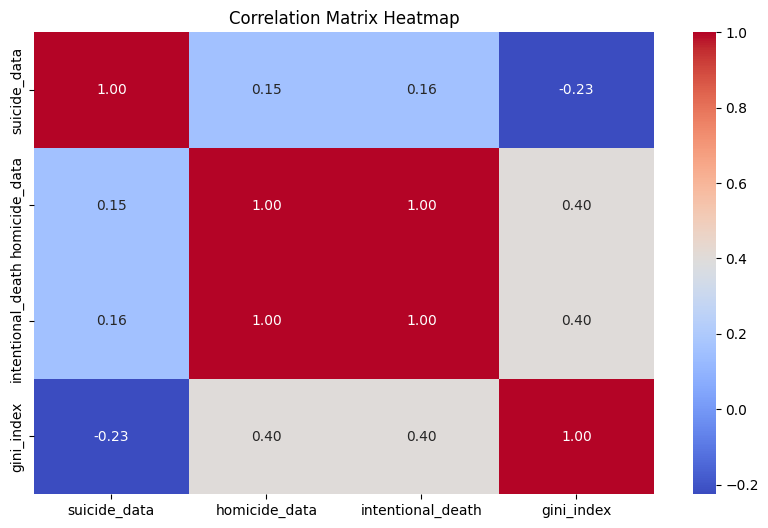

In [9]:
# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

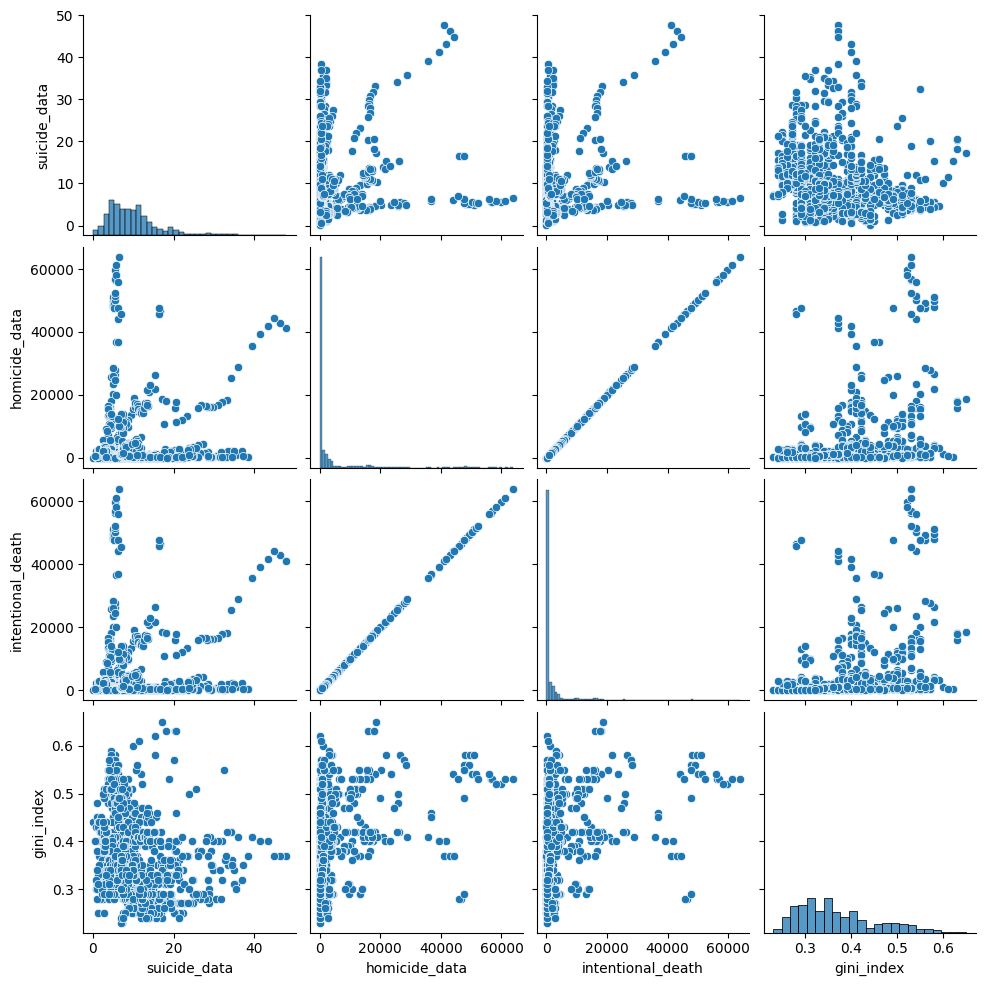

In [10]:
# Pairplot for visual relationship exploration
sns.pairplot(df[numeric_cols])
plt.show()